In [1]:
from HPNet_Pipeline import HPNet_Pipeline
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gc
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from typing import Union, List, Optional, Tuple
import sounddevice as sd
import math

LEBEDEV = 'lebedev'
POINTS_162 = '162_points'

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print("Device Name:", torch.cuda.get_device_name(DEVICE))
else:
    DEVICE = torch.device("cpu")
    print("Device Name: CPU")
torch.cuda.empty_cache()  # Free up unused memory on GPU
gc.collect()  # Clean up unused memory on CPU


Device Name: NVIDIA GeForce RTX 4080 SUPER


36

In [2]:
def plot_spectograms(anm_f,sr):
    n_fft = int(2*(anm_f.shape[-1]-1))      # Extract # FFT points from size of anm_f
    hop_length = n_fft//2   # Hop length (stride)
    win_length = n_fft   # Window length
    for channel_id in range(anm_f.shape[1]):
        plt.figure()
        magnitude = torch.abs(anm_f[:,channel_id]).t()
        freq_bins, time_frames = magnitude.shape
        sr = sr
        time_axis = (torch.arange(time_frames) * hop_length) / sr  # Time in seconds
        freq_axis = torch.arange(freq_bins) * (sr / n_fft) 
        plt.imshow(20*torch.log10(magnitude + 1e-6),
            aspect='auto', 
            origin='lower', 
            extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]],
        )
        plt.colorbar(label='Magnitude (dB)')
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [Hz]')
        plt.title(f'Spectrogram of Channel {channel_id}')
def play_sound_field_from_stft(anm_f,sr,amplify):
    n_fft = int(2*(anm_f.shape[-1]-1))      # Extract # FFT points from size of anm_f
    hop_length = n_fft//2   # Hop length (stride)
    win_length = n_fft   # Window length
    mono_signal = torch.istft(anm_f[:,0].t(),#torch.sum(anm_f, dim=1).t(),
                n_fft=n_fft,
                hop_length= hop_length,
                win_length=win_length,
                window = torch.hann_window(win_length)
                )
    mono_signal_np = mono_signal.numpy() * amplify
    sd.play(mono_signal_np, samplerate=sr)
def play_sparse_stft_sound_field(
    dict_stft: torch.tensor,
    P_ph : List[Tuple[float, float]],
    P_th : List[Tuple[float, float]],
    sr : int,
    theta: float,
    phi: float,
    radius: float = 5,
    amplify : float = 1,
    window: Union[int, None] = None,
    bin: Union[int, None] = None,
):
         
    if dict_stft.dtype == torch.complex64:
        complex_sparse_stft_dict = dict_stft
    else:
        complex_sparse_stft_dict = torch.complex(dict_stft[...,:dict_stft.shape[-1]//2],dict_stft[...,dict_stft.shape[-1]//2:])
    
    num_window_groups,num_bins,num_grid_points,T = complex_sparse_stft_dict.shape
    complex_sparse_stft_dict = complex_sparse_stft_dict.permute(2,1,0,3).reshape(num_grid_points,num_bins,num_window_groups*T).permute(2,0,1)
    n_fft = int(2*(num_bins - 1))      # Extract # FFT points from size of anm_f
    hop_length = n_fft//2   # Hop length (stride)
    win_length = n_fft   # Window length
    time_signal = torch.istft(complex_sparse_stft_dict.permute(1, 2, 0).cpu(),#torch.sum(anm_f, dim=1).t(),
        n_fft=n_fft,
        hop_length= hop_length,
        win_length=win_length,
        window = torch.hann_window(win_length)
        )


    grid_in_degress = torch.stack((P_ph, P_th)).T * 180 / torch.pi
    target_in_degress = torch.tensor([phi, theta]).reshape(1, -1)
    relevant_grid_points = (
        (torch.norm(grid_in_degress - target_in_degress, p=2, dim=1) < radius)
        .nonzero()
        .flatten()
    )

    if len(relevant_grid_points) > 0:
        print("## Playing Directions ##")
        for i in relevant_grid_points:
            print(f"{i} : Theta = {grid_in_degress[i,1]}, Phi = {grid_in_degress[i,0]}")
    else:
        print("No directions found")
        return

    energy = (time_signal**2).sum()
    normalized_time_signal = time_signal / torch.sqrt(energy)
    signal = torch.sum(normalized_time_signal[relevant_grid_points, :], axis=0)
    sd.play(amplify * signal.cpu().numpy(), sr)


In [ ]:
grid = POINTS_162
pipeline = HPNet_Pipeline(grid_type=grid)


NameError: name 'grid' is not defined

In [143]:
dataset_path = r"data\ModelDataSets\WSJ_4_3_25"
pipeline.set_dataset(dataset_path=dataset_path)

audio_id,low_order_anmt,high_order_anmt = pipeline.train_set[0]
print(audio_id,low_order_anmt.shape)
pipeline.input_order = 1
pipeline.output_order = 3


31 torch.Size([250, 4, 129])


In [144]:
pipeline.init_params(
    batch_size=1,
    n_fft=256,
    T=5,
    init_mu=1e-3,
    init_ro=1e-2,
    num_iters=10000,
    adam_lr=1e-2,
    version=1,
    device=DEVICE,
)

Optimization Method : GD_lagrange_multi 
Optimization Method : GD_lagrange_multi 


Init Upscaled Loss : None


DU_Optimizer:   0%|          | 0/10000 [00:00<?, ?it/s]

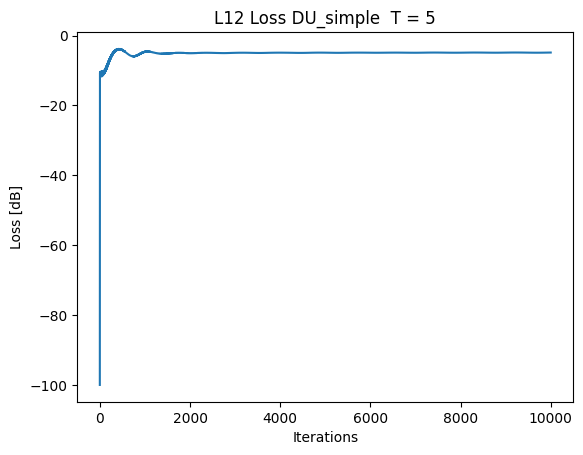

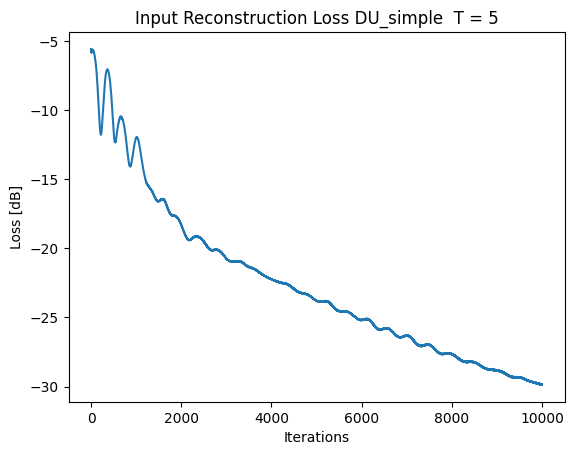

Upscaled Loss : None


In [136]:
with torch.no_grad():
    #Runs with init mu/ro only
    pipeline.run_optimizer(
        from_iter=0,
        to_iter=10000,
        low_order_stft =low_order_anmt.unsqueeze(0),
        high_order_stft = None,
        progress_per_iter=True,
        classic_model=True
    )
    print(f"Upscaled Loss : {pipeline.classic_opt.upscaled_loss(loss_in_dB=True)}")

In [150]:
pipeline.plot_dict(pipeline.classic_opt.get_current_state()[0][0],index=30)

AttributeError: 'optimizer' object has no attribute 'mask'

In [139]:
classic_opt_s_t,classic_opt_lagarange = pipeline.classic_opt.get_current_state()
play_sparse_stft_sound_field(dict_stft=classic_opt_s_t[0],P_th=pipeline.P_th,P_ph=pipeline.P_ph,theta=90,phi=45,radius=10,amplify=5,sr=pipeline.train_set.sr)

## Playing Directions ##
133 : Theta = 99.24300322695115, Phi = 45.33929672174684
157 : Theta = 80.75699677304884, Phi = 45.33929672174684


  0%|          | 0/500 [00:00<?, ?it/s]

Init Upscaled Loss : tensor([-11.6477], device='cuda:0')
Epoch 0 | UpScale Loss : -11.60104751586914 dB | Input Order Loss : -5.799516439437866 dB | L12 Loss : 0.07298719137907028
Init Upscaled Loss : tensor([-11.6477], device='cuda:0')
Epoch 1 | UpScale Loss : -11.601098775863647 dB | Input Order Loss : -5.79955518245697 dB | L12 Loss : 0.07298208028078079
Init Upscaled Loss : tensor([-11.6477], device='cuda:0')
Epoch 2 | UpScale Loss : -11.601148843765259 dB | Input Order Loss : -5.7995933294296265 dB | L12 Loss : 0.07297695428133011
Init Upscaled Loss : tensor([-11.6477], device='cuda:0')
Epoch 3 | UpScale Loss : -11.601200103759766 dB | Input Order Loss : -5.7996320724487305 dB | L12 Loss : 0.07297182828187943
Init Upscaled Loss : tensor([-11.6477], device='cuda:0')
Epoch 4 | UpScale Loss : -11.601251363754272 dB | Input Order Loss : -5.7996708154678345 dB | L12 Loss : 0.07296670973300934
Init Upscaled Loss : tensor([-11.6477], device='cuda:0')
Epoch 5 | UpScale Loss : -11.60130262

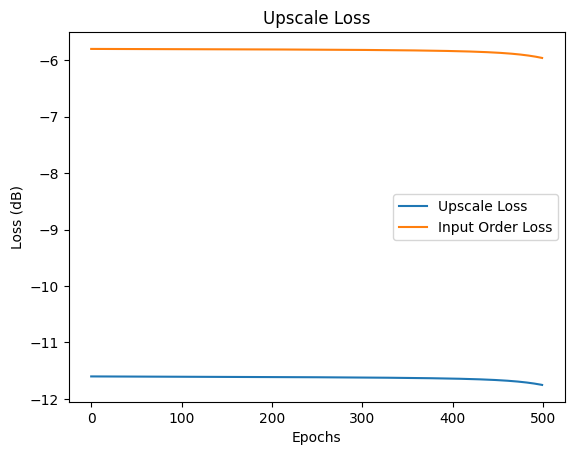

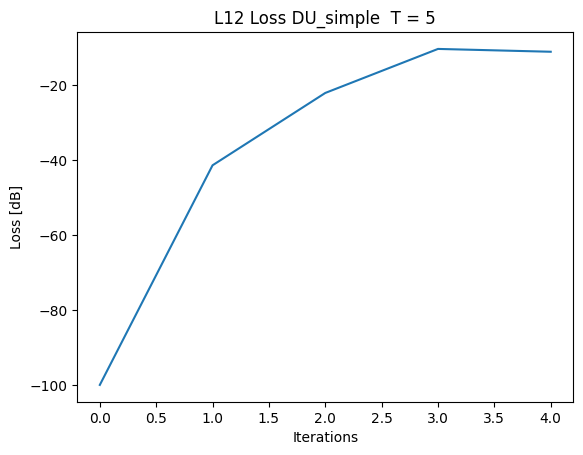

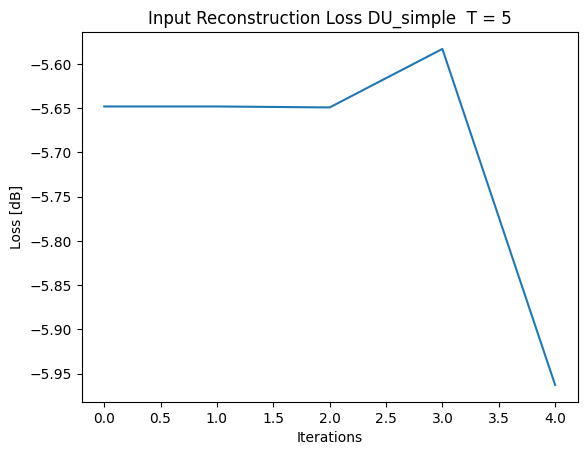

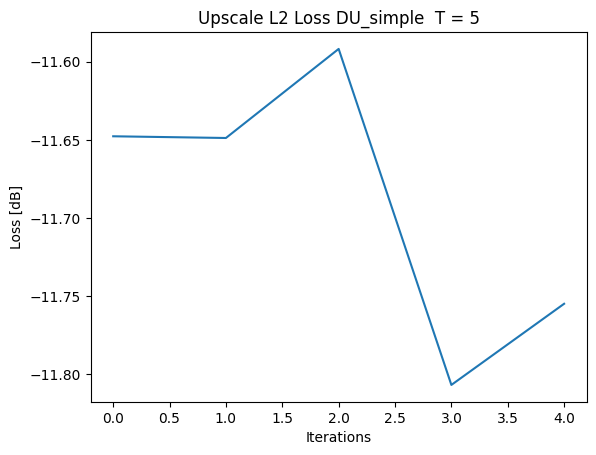

Upscaled Loss : tensor([-11.7548], device='cuda:0')


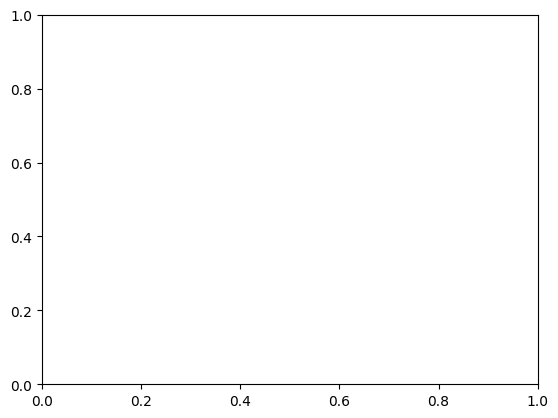

In [35]:
s_t,lagarange = None,None#pipeline.classic_opt.get_current_state()

pipeline.du_opt.init_model()
pipeline.training_opt = torch.optim.Adam(pipeline.du_opt.parameters(), lr=pipeline.adam_lr)

epochs = 500
num_iters = 5
first_iter = 0
upscale_loss_per_epoch = list()
input_order_loss_per_epoch = list()
total_loss_per_epoch = list()
mu_list = list()
ro_list = list()


for epoch in tqdm(range(epochs)):
    pipeline.run_optimizer(
        from_iter=first_iter,
        to_iter=first_iter + num_iters,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=False,
        init_lagrange=lagarange.detach().clone() if lagarange is not None else None,
        init_st=s_t.detach().clone() if s_t is not None else None,
        disable_tqdm=True,
    )
    upscale_loss  = pipeline.du_opt.upscaled_loss(p=2)
    intput_order_loss = pipeline.du_opt.input_order_loss()
    # loss = torch.sum(torch.log(1 + torch.arange(num_iters)).to(pipeline.device) * (pipeline.du_opt.gt_upscale_loss[-num_iters:])) #+ 2*pipeline.du_opt.l12_loss()
    loss = F.mse_loss(classic_opt_s_t,pipeline.du_opt.get_current_state()[0])
    pipeline.training_opt.zero_grad()
    loss.backward()
    pipeline.training_opt.step()
    upscale_loss_per_epoch.append(10*torch.log10(upscale_loss).item())
    input_order_loss_per_epoch.append(10*torch.log10(intput_order_loss).item())
    total_loss_per_epoch.append(10*torch.log10(loss).item())
    if pipeline.du_opt.HP_model.mu.numel() == 1:
        mu_list.append(pipeline.du_opt.HP_model.mu.exp().detach().cpu().item())
        ro_list.append(pipeline.du_opt.HP_model.ro.exp().detach().cpu().item())

    print(f"Epoch {epoch} | UpScale Loss : {upscale_loss_per_epoch[-1]} dB | Input Order Loss : {input_order_loss_per_epoch[-1]} dB | L12 Loss : {pipeline.du_opt.L12_loss[-1]}")

plt.plot(upscale_loss_per_epoch,label='Upscale Loss')
plt.plot(input_order_loss_per_epoch,label='Input Order Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss (dB)")
plt.title("Upscale Loss")


# s_t,lagarange = pipeline.du_opt.get_current_state()
with torch.no_grad():
    pipeline.run_optimizer(
    from_iter=first_iter,
    to_iter=first_iter + num_iters,
    low_order_stft=low_order_anmt.unsqueeze(0),
    high_order_stft=high_order_anmt.unsqueeze(0),
    progress_per_iter=True,
    disable_tqdm=True,
    init_lagrange=lagarange.detach().clone() if lagarange is not None else None,
    init_st=s_t.detach().clone() if s_t is not None else None,
)
print(f"Upscaled Loss : {pipeline.du_opt.upscaled_loss(loss_in_dB=True)}")


if pipeline.du_opt.HP_model.mu.numel() == 1:
    plt.figure()
    plt.plot(mu_list)
    plt.title("Mu")
    plt.xlabel("Epoch")
    plt.figure()
    plt.plot(ro_list)
    plt.title("Ro")
    plt.xlabel("Epoch")
else:
    try:
        plt.figure()
        plt.plot(pipeline.du_opt.HP_model.mu.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
        plt.title("Mu")
        plt.xlabel("Iterations")
        plt.figure()
        plt.plot(pipeline.du_opt.HP_model.ro.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
        plt.title("Ro")
        plt.xlabel("Iterations")
    except:
        pass
plt.show()

In [124]:
s_t,lagarange = None,None #pipeline.du_opt.get_current_state()

with torch.no_grad():
    pipeline.run_optimizer(
    from_iter=first_iter,
    to_iter=first_iter + num_iters,
    low_order_stft=low_order_anmt.unsqueeze(0),
    high_order_stft=high_order_anmt.unsqueeze(0),
    progress_per_iter=True,
    disable_tqdm=True,
    init_lagrange=lagarange.detach().clone() if lagarange is not None else None,
    init_st=s_t.detach().clone() if s_t is not None else None,
)

AttributeError: 'HPNet_Pipeline' object has no attribute 'du_opt'

In [34]:
s_t,lagarange = pipeline.du_opt.get_current_state()
play_sparse_stft_sound_field(dict_stft=s_t[0],P_th=pipeline.P_th,P_ph=pipeline.P_ph,theta=90,phi=-45,radius=10,amplify=5,sr=pipeline.train_set.sr)

## Playing Directions ##
83 : Theta = 99.24300322695115, Phi = -45.33929672174684
141 : Theta = 80.75699677304884, Phi = -45.33929672174684


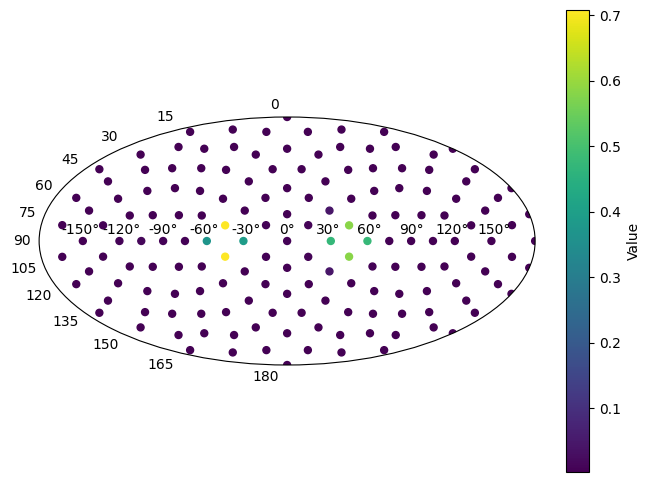

In [24]:
pipeline.plot_dict(s_t[0],index=110)

In [26]:
pipeline.du_opt.gt_stft_anmt.shape
gt_upscale_order_complex = torch.complex(pipeline.du_opt.gt_stft_anmt[...,:5],pipeline.du_opt.gt_stft_anmt[...,5:])
gt_upscale_order_complex.shape

torch.Size([1, 50, 129, 16, 5])

In [27]:
10*torch.log10(((gt_upscale_order_complex - pipeline.du_opt.upscaled_est).abs()**2).sum() / (gt_upscale_order_complex.abs()**2).sum())

tensor(-12.9769, device='cuda:0')

83 --> Theta : 99.24300322695115 Phi : -45.339296721746834
133 --> Theta : 99.24300322695115 Phi : 45.339296721746834
141 --> Theta : 80.75699677304884 Phi : -45.339296721746834
157 --> Theta : 80.75699677304884 Phi : 45.339296721746834

4


torch.Size([162, 129])

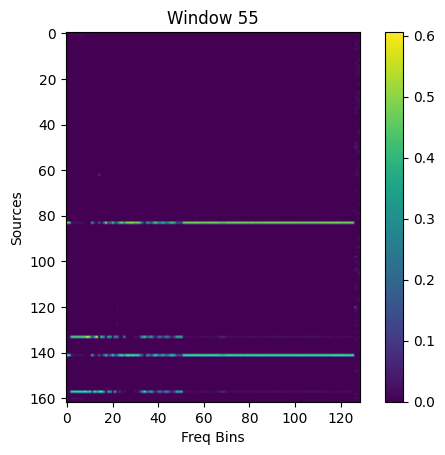

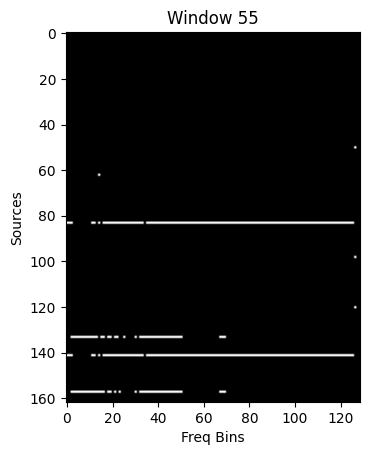

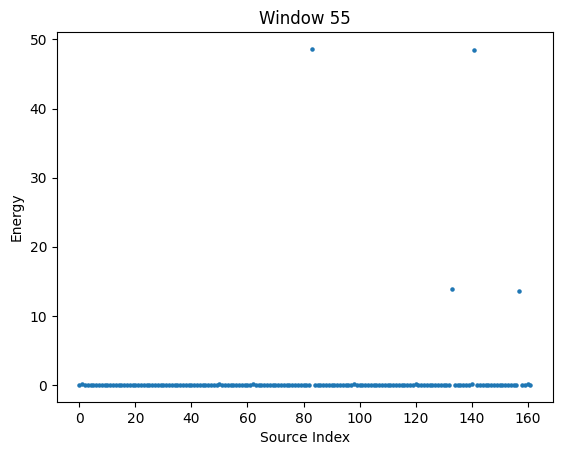

In [149]:
over_all_windows = False
window = 55


complex_sparse_stft_dict = torch.complex(s_t[...,:s_t.shape[-1]//2],s_t[...,s_t.shape[-1]//2:])[0]
num_window_groups,num_bins,num_grid_points,T = complex_sparse_stft_dict.shape
complex_sparse_stft_dict = complex_sparse_stft_dict.permute(2,1,0,3).reshape(num_grid_points,num_bins,num_window_groups*T).permute(2,0,1)
energy_per_bin_per_source = complex_sparse_stft_dict.abs()**2
if over_all_windows:
    energy_per_bin_per_source = energy_per_bin_per_source.sum(0)
    title = 'All Windows'
else:
    energy_per_bin_per_source = energy_per_bin_per_source[window]
    title = f'Window {window}'

energy_per_bin_per_source=energy_per_bin_per_source/energy_per_bin_per_source.sum(-2,keepdim=True)
plt.figure()
plt.imshow(energy_per_bin_per_source.cpu())
plt.ylabel("Sources")
plt.xlabel("Freq Bins")
plt.title(title)
plt.colorbar()
plt.figure()
plt.imshow((energy_per_bin_per_source.cpu() > 0.04).int(), cmap="gray")
plt.ylabel("Sources")
plt.xlabel("Freq Bins")
plt.title(title)



normalzed_per_source = energy_per_bin_per_source.sum(-1).cpu()
plt.figure()
plt.scatter(range(len(normalzed_per_source)),normalzed_per_source,s=5)
plt.title(title)
plt.ylabel("Energy")
plt.xlabel("Source Index")
ids_over_TH = torch.nonzero(normalzed_per_source>2)
for index in  ids_over_TH:
    print(f"{index.item()} --> Theta : {math.degrees(pipeline.P_th[index])} Phi : {math.degrees(pipeline.P_ph[index])}")
print()
print(len(torch.nonzero(normalzed_per_source>10)))
energy_per_bin_per_source.shape

DU_Optimizer:   0%|          | 0/5 [00:00<?, ?it/s]

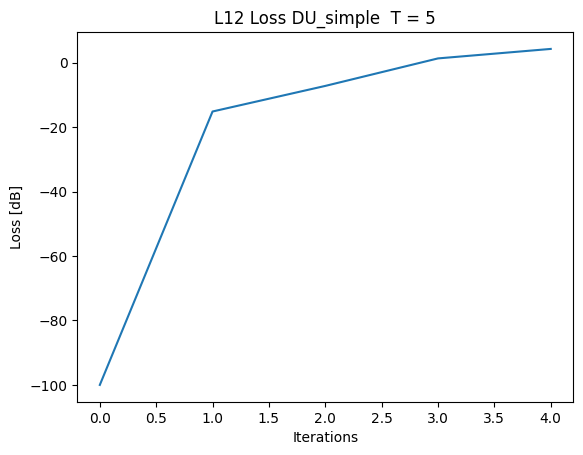

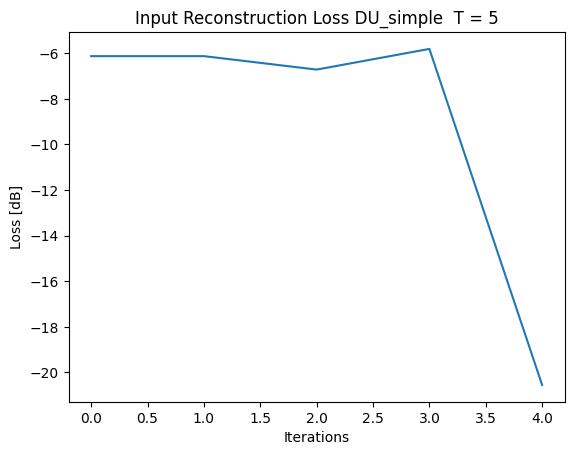

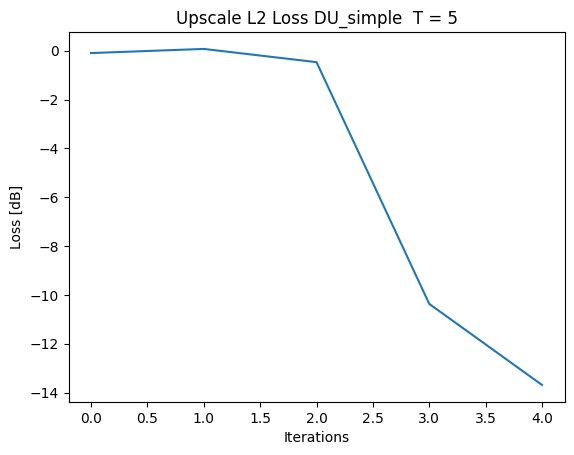

In [43]:
with torch.no_grad():
    pipeline.run_optimizer(
    from_iter=first_iter,
    to_iter=first_iter + num_iters,
    low_order_stft=low_order_anmt.unsqueeze(0),
    high_order_stft=high_order_anmt.unsqueeze(0),
    progress_per_iter=True,
    disable_tqdm=False,
    init_lagrange=None, #lagarange.detach().clone() if lagarange is not None else None,
    init_st=None #s_t.detach().clone() if s_t is not None else None,
)

In [23]:
classic_opt_s_t,classic_opt_lagarange = pipeline.classic_opt.get_current_state()


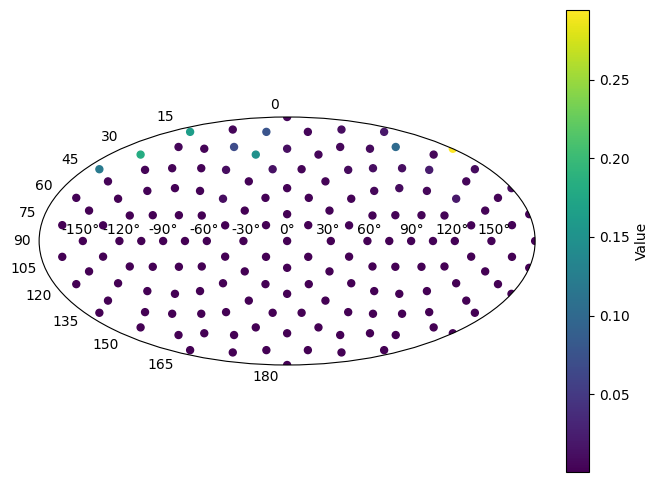

In [24]:
pipeline.plot_dict(pipeline.du_opt.get_current_state()[0][0],index=200)

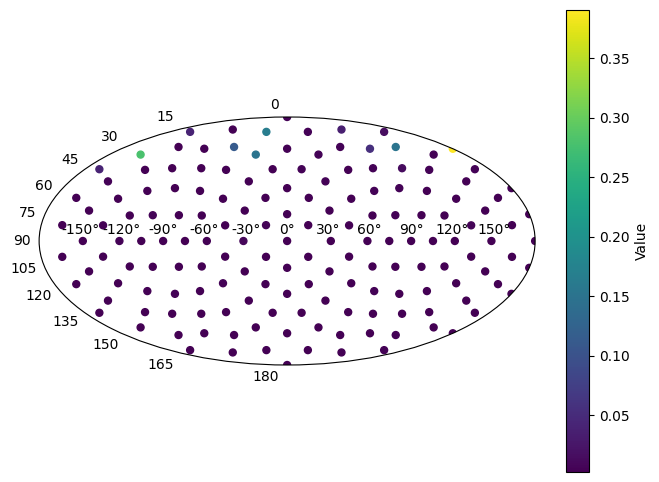

In [14]:
pipeline.plot_dict(classic_opt_s_t[0],index=200)

  0%|          | 0/300 [00:00<?, ?it/s]

Init Upscaled Loss : tensor([-5.6481], device='cuda:0')
Epoch 0 | UpScale Loss : -5.62032413482666 dB | Input Order Loss : -12.082908630371094 dB | L12 Loss : -11.088184356689453
Init Upscaled Loss : tensor([-5.6481], device='cuda:0')
Epoch 1 | UpScale Loss : -5.634359836578369 dB | Input Order Loss : -12.092114448547363 dB | L12 Loss : -11.51629638671875
Init Upscaled Loss : tensor([-5.6481], device='cuda:0')
Epoch 2 | UpScale Loss : -5.647707462310791 dB | Input Order Loss : -12.101187705993652 dB | L12 Loss : -11.774102210998535
Init Upscaled Loss : tensor([-5.6481], device='cuda:0')
Epoch 3 | UpScale Loss : -5.660317420959473 dB | Input Order Loss : -12.110177040100098 dB | L12 Loss : -11.91098403930664
Init Upscaled Loss : tensor([-5.6481], device='cuda:0')
Epoch 4 | UpScale Loss : -5.672305107116699 dB | Input Order Loss : -12.119293212890625 dB | L12 Loss : -11.981154441833496
Init Upscaled Loss : tensor([-5.6481], device='cuda:0')
Epoch 5 | UpScale Loss : -5.683504104614258 dB 

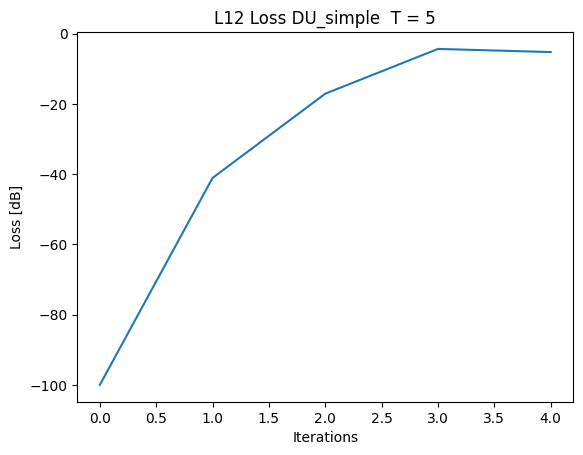

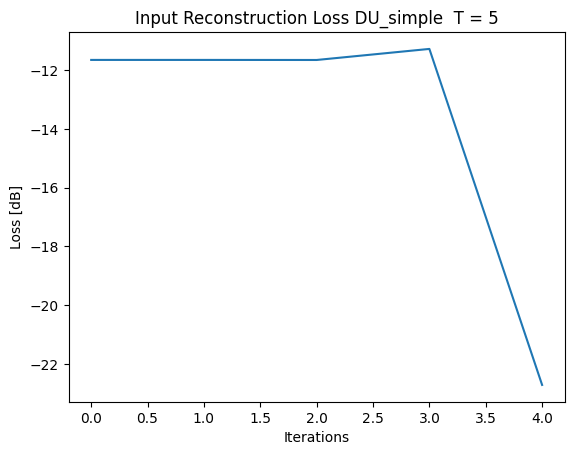

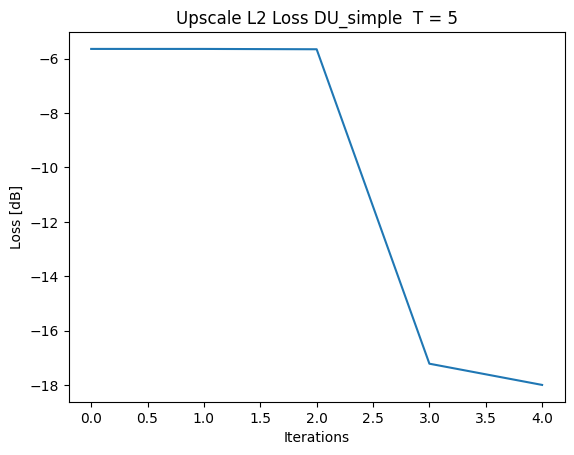

  0%|          | 0/300 [00:00<?, ?it/s]

Init Upscaled Loss : tensor([-17.9917], device='cuda:0')
Epoch 0 | UpScale Loss : -17.677227020263672 dB | Input Order Loss : -25.009254455566406 dB | L12 Loss : -4.469151020050049
Init Upscaled Loss : tensor([-17.9917], device='cuda:0')
Epoch 1 | UpScale Loss : -17.8366641998291 dB | Input Order Loss : -24.97006607055664 dB | L12 Loss : -5.015616416931152
Init Upscaled Loss : tensor([-17.9917], device='cuda:0')
Epoch 2 | UpScale Loss : -17.949859619140625 dB | Input Order Loss : -24.89508819580078 dB | L12 Loss : -5.570268630981445
Init Upscaled Loss : tensor([-17.9917], device='cuda:0')
Epoch 3 | UpScale Loss : -18.019832611083984 dB | Input Order Loss : -24.805599212646484 dB | L12 Loss : -5.937163829803467
Init Upscaled Loss : tensor([-17.9917], device='cuda:0')
Epoch 4 | UpScale Loss : -18.05413055419922 dB | Input Order Loss : -24.79255485534668 dB | L12 Loss : -5.805150032043457
Init Upscaled Loss : tensor([-17.9917], device='cuda:0')
Epoch 5 | UpScale Loss : -18.06466293334961 

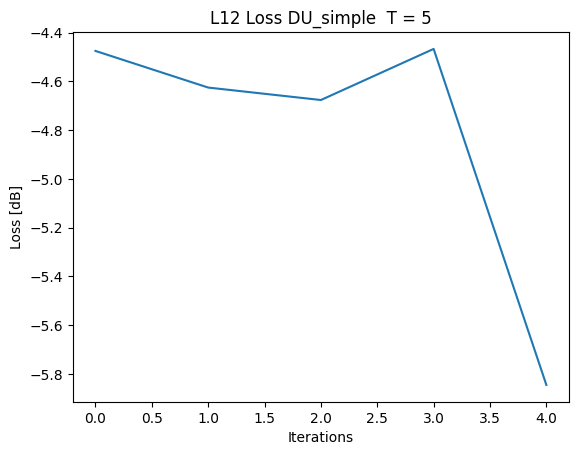

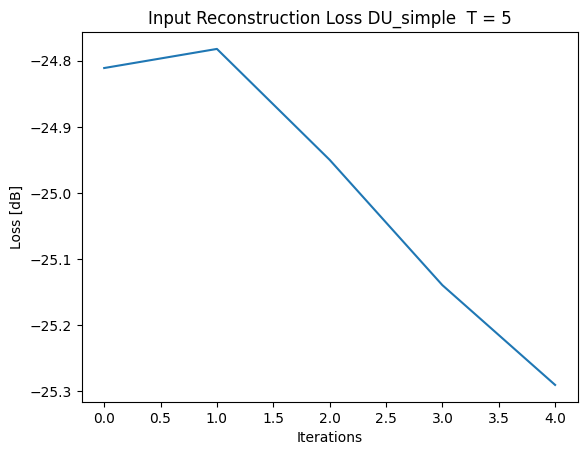

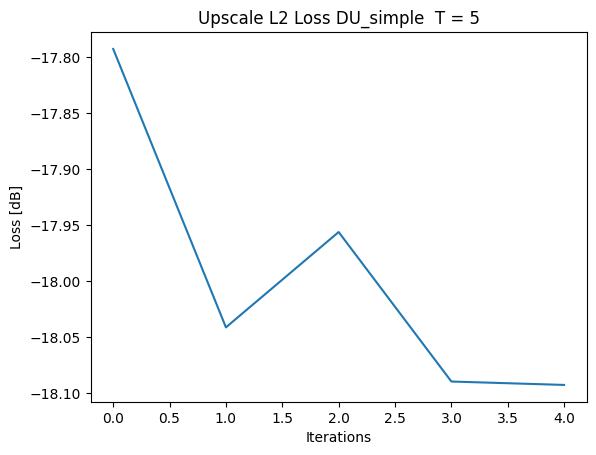

Text(0.5, 1.0, 'Upscale Loss')

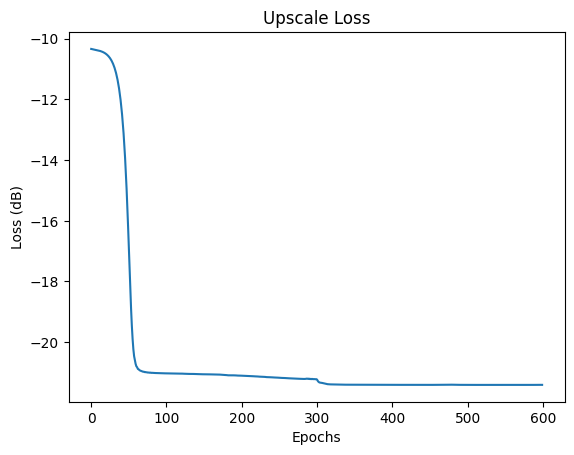

In [145]:
pipeline.du_opt.init_model()
epochs = 300
num_iters = 5
loss_per_epoch = list()
iter_groups = torch.arange(0, 10, num_iters)
init_st = None
init_lagarange = None
for group_num,first_iter in enumerate(iter_groups):
    pipeline.training_opt = torch.optim.Adam(pipeline.du_opt.parameters(), lr=1e-1)
    for epoch in tqdm(range(epochs)):
        pipeline.run_optimizer(
            from_iter=first_iter,
            to_iter=first_iter + num_iters,
            low_order_stft=low_order_anmt.unsqueeze(0),
            high_order_stft=high_order_anmt.unsqueeze(0),
            progress_per_iter=False,
            disable_tqdm=True,
            init_lagrange=init_lagarange.detach() if init_lagarange is not None else None,
            init_st=init_st.detach() if init_st is not None else None,
        )
        loss = (torch.norm(classic_opt_s_t - pipeline.du_opt.get_current_state()[0], p=2, dim = (-2,-1))**2).mean()
        # loss = torch.sum(torch.log(1 + torch.arange(num_iters)).to(pipeline.device) * (pipeline.du_opt.gt_upscale_loss[-num_iters:] + pipeline.du_opt.reconstruction_loss[-num_iters:])) #+ 2*pipeline.du_opt.l12_loss()
        # loss = 4 *pipeline.du_opt.upscaled_loss() +  pipeline.du_opt.input_order_loss()
        curr_state= pipeline.du_opt.get_current_state()[0]
        # loss = torch.norm(curr_state-classic_opt_s_t,p=2,dim=(-1,-2)).mean()
        pipeline.training_opt.zero_grad()
        loss.backward()
        pipeline.training_opt.step()
        loss_per_epoch.append(10*torch.log10(loss).item())
        print(f"Epoch {epoch} | UpScale Loss : {10*torch.log10(pipeline.du_opt.gt_upscale_loss[-1])} dB | Input Order Loss : {10*torch.log10(pipeline.du_opt.reconstruction_loss[-1])} dB | L12 Loss : {10*torch.log10(pipeline.du_opt.L12_loss[-1])}")

    with torch.no_grad():
        pipeline.run_optimizer(
        from_iter=first_iter,
        to_iter=first_iter + num_iters,
        low_order_stft=low_order_anmt.unsqueeze(0),
        high_order_stft=high_order_anmt.unsqueeze(0),
        progress_per_iter=True,
        disable_tqdm=True,
        init_lagrange=init_lagarange.detach() if init_lagarange is not None else None,
        init_st=init_st.detach() if init_st is not None else None,
    )
    # print(f"Finished Iteration Group {first_iter} - {first_iter + num_iters} : ")
    # plt.figure()
    # plt.plot(pipeline.du_opt.HP_model.mu.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
    # plt.title("Mu")
    # plt.figure()
    # plt.plot(pipeline.du_opt.HP_model.ro.exp().detach().cpu()[first_iter:first_iter + num_iters].squeeze())
    # plt.title("Ro")
    # plt.show()
    init_st ,init_lagarange = pipeline.du_opt.get_current_state() #assumes last epoch is best - TODO save best result and move from it

plt.plot(loss_per_epoch)
plt.xlabel("Epochs")
plt.ylabel("Loss (dB)")
plt.title("Upscale Loss")

Init Upscaled Loss : tensor([-9.6282], device='cuda:0')


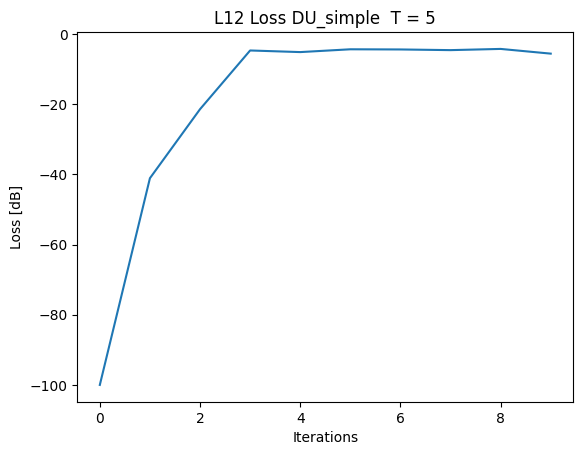

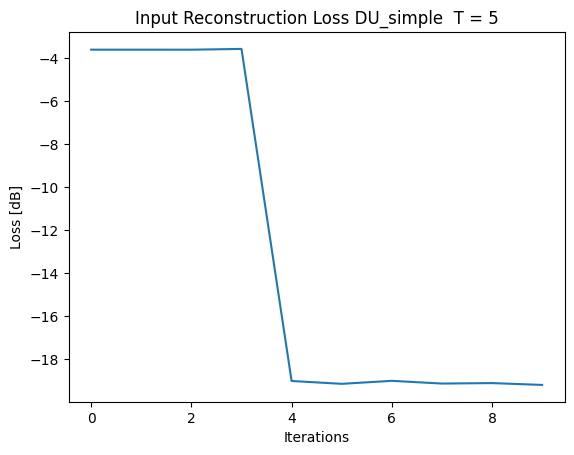

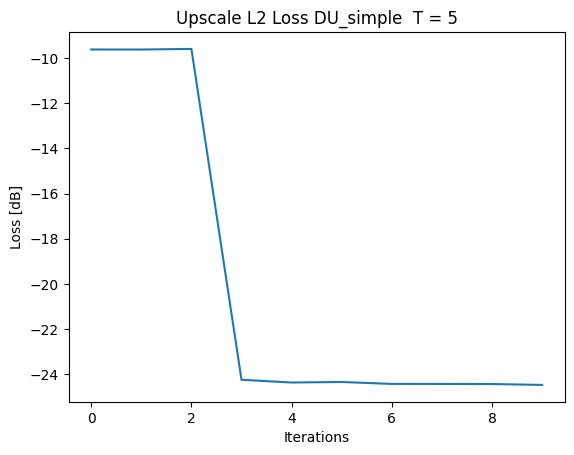

In [117]:
with torch.no_grad():
    pipeline.run_optimizer(
    from_iter=0,
    to_iter=10,
    low_order_stft=low_order_anmt.unsqueeze(0),
    high_order_stft=high_order_anmt.unsqueeze(0),
    progress_per_iter=True,
    disable_tqdm=True,
    init_lagrange= None,
    init_st=None,
)

In [147]:
s_t,lagarange = pipeline.du_opt.get_current_state()
play_sparse_stft_sound_field(dict_stft=s_t[0].detach(),P_th=pipeline.P_th,P_ph=pipeline.P_ph,theta=90,phi=45,radius=10,amplify=3,sr=pipeline.train_set.sr)

## Playing Directions ##
133 : Theta = 99.24300322695115, Phi = 45.33929672174684
157 : Theta = 80.75699677304884, Phi = 45.33929672174684


In [105]:
s_t.shape

torch.Size([1, 50, 129, 162, 10])

In [90]:
max_id = pipeline.du_opt.HP_model.ro.exp()[5:9].argmax()
torch.unravel_index(max_id, pipeline.du_opt.HP_model.ro.exp().shape)


(tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'))

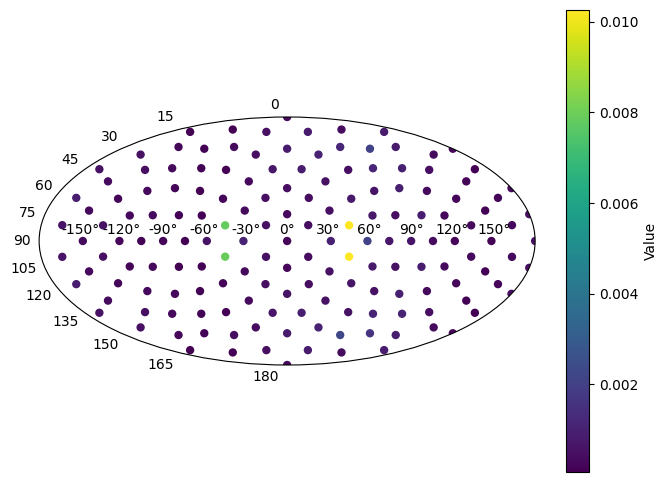

In [148]:
pipeline.plot_dict(s_t[0].detach(),index=30)